# Isotropic coordinate system transformations

Radial basis functions are *isotropic*: they depend only on $\|x - c\|$, so the model assumes the response varies at the same rate in every direction. Real responses rarely do. The mismatch shows up as model bias, and it is why adding gradient information to a surrogate can fail to improve it — the extra information ends up fighting the functional form rather than informing it.

The fix is a pre-processing step: estimate a rotation and a per-direction scaling that make the data manifold roughly isotropic, express the samples *and their gradients* in that frame, and fit there.

This notebook uses the paper's test problem, which is decomposable by construction, so the ideal frame is known exactly. Rotating it couples the variables, and a transformation scheme then has to recover both a rotation and a scaling.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import qmc

from ge_rbf import IsotropicTransformer, RBFRegressor, gradient_search
from ge_rbf.problems import non_isotropic, random_rotation

rotation = random_rotation(2, rng=5)

X = qmc.LatinHypercube(d=2, seed=1).random(25)
y, dy = non_isotropic(X, rotation)

print(f"{X.shape[0]} samples in {X.shape[1]} dimensions")
print("rotation used to couple the variables:")
print(np.round(rotation, 4))

25 samples in 2 dimensions
rotation used to couple the variables:
[[ 0.6064  0.7952]
 [-0.7952  0.6064]]


## Estimating the frame

The transformer estimates curvature, then takes its eigenvectors as the rotation and the square roots of its eigenvalues as the scaling. `"ge-lhm"` builds local Hessians from the sampled gradients using symmetric rank-one updates — it needs only `n + 1` points per estimate, so it scales linearly with dimension.

In [2]:
frame = IsotropicTransformer(method="ge-lhm").fit(X, y=y, dy=dy)

print("estimated curvature:")
print(np.round(frame.curvature_, 3))
print(f"\neigenvalues: {np.round(frame.eigenvalues_, 3)}")
print(f"scaling:     {np.round(frame.scaling_, 3)}")
print(f"\nanisotropy ratio: {frame.eigenvalues_[0] / frame.eigenvalues_[-1]:.1f}x")

estimated curvature:
[[21.647 13.795]
 [13.795 15.023]]

eigenvalues: [32.522  4.148]
scaling:     [5.703 2.037]

anisotropy ratio: 7.8x


The transformer holds the frame and nothing else — it never modifies the estimator or the data you give it. You apply it explicitly, and gradients need their own conversion because rotating and scaling the coordinates changes what a gradient means.

In [3]:
X_frame = frame.transform(X)
dy_frame = frame.transform_gradient(dy)

# Round trips exactly.
print(f"inverse_transform recovers X:  {np.allclose(frame.inverse_transform(X_frame), X)}")
print(
    f"and the gradients:             {np.allclose(frame.inverse_transform_gradient(dy_frame), dy)}"
)

inverse_transform recovers X:  True
and the gradients:             True


## Does it help?

Fit a gradient-enhanced model both ways, selecting the shape parameter independently in each frame so the comparison is fair, and measure the error on a dense grid.

In [4]:
grid = np.linspace(0, 1, 60)
gx, gy = np.meshgrid(grid, grid)
points = np.column_stack([gx.ravel(), gy.ravel()])
truth, _ = non_isotropic(points, rotation)


def fit_and_score(transformer=None):
    """Select a shape parameter and fit, optionally in a transformed frame."""
    if transformer is None:
        fit_X, fit_dy, test_X = X, dy, points
    else:
        fit_X = transformer.transform(X)
        fit_dy = transformer.transform_gradient(dy)
        test_X = transformer.transform(points)

    found = gradient_search(RBFRegressor(), fit_X, y, fit_dy, max_condition=1e13)
    prediction = found.best_estimator.predict(test_X)
    return prediction, np.linalg.norm(prediction - truth) / np.linalg.norm(truth), found


baseline, baseline_error, baseline_search = fit_and_score()
transformed, transformed_error, transformed_search = fit_and_score(frame)

print(
    f"original frame:    eps={baseline_search.best_epsilon:.3f}, relative error {baseline_error:.2%}"
)
print(
    f"transformed frame: eps={transformed_search.best_epsilon:.3f}, relative error {transformed_error:.2%}"
)

original frame:    eps=0.596, relative error 1.32%
transformed frame: eps=0.031, relative error 0.36%


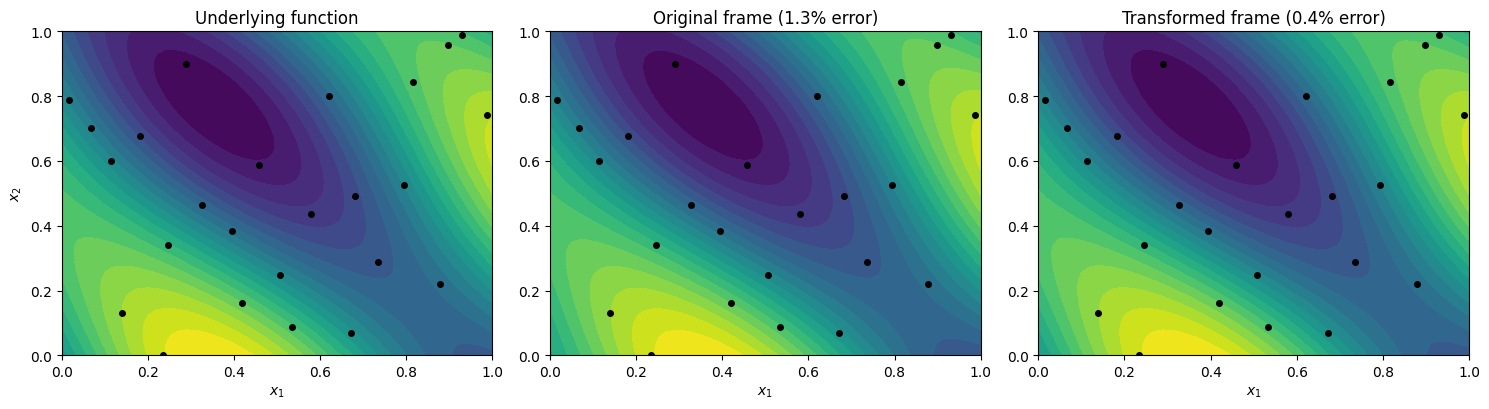

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
levels = np.linspace(truth.min(), truth.max(), 21)

for ax, (field, title) in zip(
    axes,
    [
        (truth, "Underlying function"),
        (baseline, f"Original frame ({baseline_error:.1%} error)"),
        (transformed, f"Transformed frame ({transformed_error:.1%} error)"),
    ],
    strict=True,
):
    ax.contourf(gx, gy, field.reshape(gx.shape), levels=levels)
    ax.plot(X[:, 0], X[:, 1], "k.", markersize=8)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")

axes[0].set_ylabel("$x_2$")
fig.tight_layout()

## Comparing the estimation methods

- **`ge-lhm`** — local Hessians from gradients. Needs `n + 1` points per estimate.
- **`ge-dlhm`** — the same, but keeping only the diagonal: component-wise scaling with no rotation. This is what conventional cross-validated scaling amounts to, and on a coupled problem it should help noticeably less.
- **`fv-lhm`** — local quadratic fits to function values. Needs `n(n+1)/2 + n + 1` points per estimate, so it becomes expensive quickly.
- **`asm`** — the active subspace method: one global measure rather than many local ones.
- **`ideal`** — a frame you supply. Here we know the answer, so we can supply it.

In [6]:
results = {"no transformation": baseline_error}

for method in ("ge-lhm", "ge-dlhm", "fv-lhm", "asm"):
    candidate = IsotropicTransformer(method=method).fit(X, y=y, dy=dy)
    results[method] = fit_and_score(candidate)[1]

# The ideal frame uses the exact rotation the problem was built with. The scaling
# still has to come from somewhere, so we estimate curvature in the decomposable
# frame and take its diagonal -- in axis order, not sorted, so that each scaler
# stays paired with the axis it belongs to.
decomposable = IsotropicTransformer(method="ge-lhm").fit(X @ rotation, dy=dy @ rotation)
ideal = IsotropicTransformer(
    method="ideal", rotation=rotation, scaling=np.sqrt(np.diag(decomposable.curvature_))
).fit(X)
results["ideal"] = fit_and_score(ideal)[1]

for name, error in sorted(results.items(), key=lambda item: item[1]):
    print(f"{name:>20s}: {error:.2%}")

              fv-lhm: 0.31%
              ge-lhm: 0.36%
               ideal: 0.50%
             ge-dlhm: 0.67%
                 asm: 0.93%
   no transformation: 1.32%


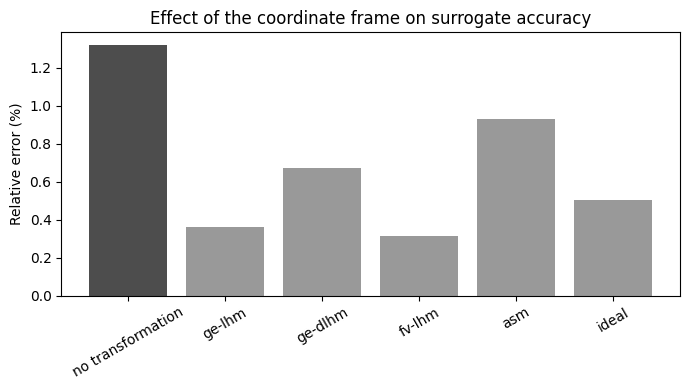

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(results)
ax.bar(names, [results[n] * 100 for n in names], color="0.6")
ax.bar(["no transformation"], [results["no transformation"] * 100], color="0.3")
ax.set_ylabel("Relative error (%)")
ax.set_title("Effect of the coordinate frame on surrogate accuracy")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

Every transformation beats no transformation. The ordering is the paper's: the methods that estimate a full rotation (`ge-lhm`, `fv-lhm`) do better than component-wise scaling alone (`ge-dlhm`), which does better than the global `asm` measure.

Note that `ideal` — using the exact rotation the problem was built with — is *not* the winner here. That is not a contradiction. Only the rotation is known exactly; its scaling still has to be estimated from the same 25 samples, and at this sample count the estimated frames are already close enough that the remaining differences are sampling noise. That the local methods reach the ideal frame so quickly is the point being made.

## A caveat

The test problem here is decomposable, so an ideal frame genuinely exists and the methods can find it. On a problem whose Hessian varies strongly across the domain there may be no single global frame worth finding, and the transformation will offer little. Section 7 of the paper covers this limitation.